In [24]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pickle as pkl
import warnings
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import wandb
from sklearn.metrics import recall_score
import gc

if torch.cuda.is_available():
    torch.device('cuda')
    print("Using the GPU!")

tqdm.pandas()

#test hello

Using the GPU!


In [25]:
train_df = pd.read_csv('~/data/train_df_clean.csv',index_col=0)
test_df = pd.read_csv('~/data/test_df_clean.csv')
dev_df = pd.read_csv('~/data/dev_df_clean.csv')


print(train_df.shape)
print(test_df.shape)
print(dev_df.shape)

(74724, 6)
(23353, 6)
(18682, 6)


In [26]:
warnings.simplefilter('error', Image.DecompressionBombWarning)


def get_tot_chans(ind,img_id,set_name,img_dir='/home/tyler_mlboss/data',drop_inds=[]):
    sums=np.zeros(7)

    try:
        img = plt.imread(f"{img_dir}/{set_name}/{img_id}.jpg")  

        # Red normal and squared
        sums[0] += np.sum(img[:,:,0])
        sums[1] += np.sum(np.square(img[:,:,0].astype(np.float64)))

        #Green normal and squared
        sums[2] += np.sum(img[:,:,1])
        sums[3] += np.sum(np.square(img[:,:,1].astype(np.float64)))

        #Blue normal and squared
        sums[4] += np.sum(img[:,:,2])
        sums[5] += np.sum(np.square(img[:,:,2].astype(np.float64)))
        
        sums[6] += (img.shape[0] * img.shape[1])

        
          
    except Exception as e:
        #print(e)
        drop_inds.append(ind)
        return [np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
        
        
    
    return (
        sums
    )

In [7]:
drop_train = []
drop_test = []
drop_dev = []

train_df[['tot_r','tot_r_sq','tot_g','tot_g_sq','tot_b','tot_b_sq','tot_pixs']] = train_df.progress_apply(lambda x: get_tot_chans(x.name,x['id'],'train',drop_inds=drop_train),axis=1,result_type='expand')
dev_df[['tot_r','tot_r_sq','tot_g','tot_g_sq','tot_b','tot_b_sq','tot_pixs']] = dev_df.progress_apply(lambda x: get_tot_chans(x.name,x['id'],'dev',drop_inds=drop_dev),axis=1,result_type='expand')
test_df[['tot_r','tot_r_sq','tot_g','tot_g_sq','tot_b','tot_b_sq','tot_pixs']] = test_df.progress_apply(lambda x: get_tot_chans(x.name,x['id'],'test',drop_inds=drop_test),axis=1,result_type='expand')

100%|██████████| 23353/23353 [05:12<00:00, 74.79it/s] 


In [27]:
train_df = train_df.dropna().reset_index(drop=True)
dev_df = dev_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)


print(train_df.shape)
print(test_df.shape)
print(dev_df.shape)

(74724, 6)
(23353, 6)
(18682, 6)


In [9]:
def save_col_info_np(df,set_name):
    avg_chan_nps = '/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/avg_chans'

    chans_inf_arr = np.array(df[['tot_r','tot_r_sq','tot_g','tot_g_sq','tot_b','tot_b_sq','tot_pixs']])

    np.save(f'{avg_chan_nps}/{set_name}_col_chan_inf.npy',chans_inf_arr)
    

In [10]:
#os.mkdir('/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/avg_chans')

#train_df.to_csv('/home/tyler_mlboss/data/train_df_clean.csv',index=False)
save_col_info_np(train_df,'train')
save_col_info_np(dev_df,'dev')
save_col_info_np(test_df,'test')

In [28]:
def load_col_info_np(df,set_name):
    # ['tot_r','tot_r_sq','tot_g','tot_g_sq','tot_b','tot_b_sq','tot_pixs']
    avg_chan_nps = '/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/avg_chans'

    loaded_col_inf = np.load(f'{avg_chan_nps}/{set_name}_col_chan_inf.npy')

    df['tot_r'] = loaded_col_inf[:,0]
    df['tot_r_sq'] = loaded_col_inf[:,1]
    
    df['tot_g'] = loaded_col_inf[:,2]
    df['tot_g_sq'] = loaded_col_inf[:,3]
    
    df['tot_b'] = loaded_col_inf[:,4]
    df['tot_b_sq'] = loaded_col_inf[:,5]
    
    df['tot_pixs'] = loaded_col_inf[:,6]

In [29]:
load_col_info_np(train_df,'train')
load_col_info_np(dev_df,'dev')
load_col_info_np(test_df,'test')

In [30]:
def calc_mean_chans(df):
    mean_chan_tup = np.zeros(3)

    i = 0
    for chan in ['r','g','b']:
        chan_vals = df[f'tot_{chan}']

        mean_chan_tup[i] = chan_vals.sum()/df['tot_pixs'].sum()

        i += 1

    return mean_chan_tup

def calc_std_chans(df,chan_means):
    i = 0
    

    std_chan_tup = np.zeros(3)

    for chan in ['r','g','b']:
        chan_vals_sq = df[f'tot_{chan}_sq']

        chan_var = (chan_vals_sq.sum()/df['tot_pixs'].sum())-(chan_means[i]**2)

        std_chan_tup[i] = np.sqrt(chan_var)

        i += 1

    return std_chan_tup


In [31]:
train_raw_means = calc_mean_chans(train_df)
dev_raw_means = calc_mean_chans(dev_df)
test_raw_means = calc_mean_chans(test_df)

train_raw_std = calc_std_chans(train_df,train_raw_means)
dev_raw_std = calc_std_chans(dev_df,train_raw_means)
test_raw_std = calc_std_chans(test_df,train_raw_means)


train_adj_mean = train_raw_means/255
dev_adj_mean = dev_raw_means/255
test_adj_mean = test_raw_means/255

train_adj_std = train_raw_std/255
dev_adj_std = dev_raw_std/255
test_adj_std = test_raw_std/255

print(f"Train mean: {train_adj_mean}, std:{train_adj_std}")
print(f"Dev mean: {dev_adj_mean}, std:{dev_adj_std}")
print(f"Test mean: {test_adj_mean}, std:{test_adj_std}")

Train mean: [0.45661377 0.43411035 0.40786523], std:[0.29919911 0.28872922 0.29697153]
Dev mean: [0.45261119 0.4305528  0.40339562], std:[0.29616078 0.2858011  0.29199199]
Test mean: [0.45318004 0.43208229 0.40681247], std:[0.2928699  0.28467298 0.29464008]


In [32]:
# First defining the transform pipline that will be ran on each image
# when loaded.

img_trans = transforms.Compose([
    transforms.Resize((227,227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_adj_mean,std=train_adj_std)
    
])

# NOTE TO SELF PASS IN DFS as record dicts here
class ImagesCustDataset(Dataset):
    def __init__(self,image_data,text_data,labels,set_name):
        self.data = data
        self.labels = labels
        self.transform = img_trans
        self.img_dir = '/home/tyler_mlboss/data'
        self.set_name = set_name

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):
        img_id = self.data[idx]
        img = Image.open(f"{self.img_dir}/{self.set_name}/{img_id}.jpg")

        img_tens = self.transform(img)

        return img_tens, self.labels[idx]

In [33]:
train_df_ids = list(train_df['id'])
train_df_labs = list(train_df['2_way_label'])
train_ds = ImagesCustDataset(train_df_ids,train_df_labs,'train')


dev_df_ids = list(dev_df['id'])
dev_df_labs = list(dev_df['2_way_label'])
dev_ds = ImagesCustDataset(dev_df_ids,dev_df_labs,'dev')

test_df_ids = list(test_df['id'])
test_df_labs = list(test_df['2_way_label'])
test_ds = ImagesCustDataset(test_df_ids,test_df_labs,'test')

# This guide was used to construct the rest of the code for building the model below.

https://www.digitalocean.com/community/tutorials/vgg-from-scratch-pytorch

In [34]:

class VGG16(nn.Module):
    def __init__(self, num_classes=2):
        super(VGG16, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer5 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer6 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer7 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer8 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer9 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer10 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer11 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer12 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer13 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(7*7*512, 4096),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Linear(4096, num_classes))
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = self.layer7(out)
        out = self.layer8(out)
        out = self.layer9(out)
        out = self.layer10(out)
        out = self.layer11(out)
        out = self.layer12(out)
        out = self.layer13(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

In [18]:
num_epochs = 20
batch_size = 16
learning_rate = 0.005
device= torch.device('cuda')

model = VGG16().to(device)

loss_calc = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9) 

train_dl = DataLoader(train_ds,shuffle=True,batch_size=batch_size)
dev_dl = DataLoader(dev_ds,shuffle=True,batch_size=batch_size)
test_dl = DataLoader(test_ds,shuffle=True,batch_size=batch_size)

In [13]:
run = wandb.init(
    project="CSC480-VGG16-Project",
    config={
        "learning_rate": learning_rate,
        "architecture": "VGG16-from-scratch",
        "dataset": "Custom-V2",
        "epochs": num_epochs,
    }
)

# Now start the training loop
for epoch in range(run.config.epochs):

    model.train()

    train_loss = 0
    epoch_train_loss = 0
    
    
    for batch_ind, (imgs, labs) in enumerate(train_dl):

        imgs = imgs.to(device)
        labs = labs.to(device)

        # Foward
        outputs = model(imgs)
        loss = loss_calc(outputs,labs)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss = loss.item()
        epoch_train_loss += train_loss

        if batch_ind % 50 == 0:
            print(train_loss)
            run.log({'batch_loss':train_loss})

    model.eval()
    pred_labs = []
    correct_labs = []
    
    with torch.no_grad():

        for imgs,labs in dev_dl:

            imgs = imgs.to(device)
            labs = labs.to(device)

            
            outputs = model(imgs)
            pred = torch.argmax(outputs.data,dim=1)

            correct_labs.extend(labs.cpu().numpy())
            pred_labs.extend(pred.cpu().numpy())

            # Make a clean slate
            del imgs,labs,outputs


    # Now checkpointing
    avg_loss = epoch_train_loss/len(train_dl)
    val_rec = recall_score(correct_labs,pred_labs,zero_division=0)
    run.log({'epoch_val_recall':val_rec,'avg_train_loss':avg_loss,'epoch':epoch})


    checkpoint = {
        'epoch':epoch,
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict()
    }

    torch.save(checkpoint,f"/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/vgg16_checpoints/vgg_mod_checpt{epoch}.pt")

torch.save(model.state_dict(), "/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/vgg16_checpoints/vgg16_weights_final.pt")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/tyler_mlboss/.netrc.
wandb: Currently logged in as: tyleraarong (tyleraarong-university-of-arizona) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


0.7055465579032898
0.949113130569458
0.6357592940330505
0.703340470790863
0.637561559677124
0.6255086660385132
0.7404816150665283
0.7215906977653503
0.7315590381622314
0.8115030527114868
0.7582268118858337
0.6562089920043945
0.6157635450363159
0.7442291378974915
0.5885369181632996
0.6627138257026672
0.6629593968391418
0.5868828892707825
0.71745365858078
0.7444459795951843
0.7677581906318665
0.5287426710128784
0.653722882270813
0.5870157480239868
0.7452487349510193
0.6269625425338745
0.6073367595672607
0.6350260972976685
0.6822093725204468
0.6238800287246704
0.6168500781059265
0.6611045002937317
0.7333317399024963
0.7232011556625366
0.6387154459953308
0.6848575472831726
0.6110415458679199
0.6897677779197693
0.7989567518234253
0.6609988212585449
0.7153233289718628
0.5568008422851562
0.5869526267051697
0.5531602501869202
0.6930563449859619
0.7001665234565735
0.5840843319892883
0.6622481346130371
0.7147683501243591
0.604315459728241
0.635301947593689
0.5558316707611084
0.6658971309661865
0

In [14]:
run.finish()

avg_train_loss,█▆▃▂▂▂▂▂▂▂▂▁▁▁▁▁▂▂▁▁
batch_loss,▆▅▄▅▅▅▃▂▃▁▄█▄▃▃▂▁▃▂▂▂▄▃▂▃▅▆▃▂▃▃▂▄▂▂▆▂▃▂▂
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch_val_recall,▁▇▄▆█▅▆█▆▇▄█▇▇▇▆▇██▇
avg_train_loss,0.45899
batch_loss,0.30396
epoch,19
epoch_val_recall,0.90599


In [17]:
model.to('cpu')
del model
del optimizer
del checkpoint
gc.collect()
torch.cuda.empty_chache()

NameError: name 'model' is not defined

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay
def evaluate(y_pred, y_true):
  accuracy = accuracy_score(y_true, y_pred)
  macro_precision = precision_score(y_true, y_pred, zero_division=0,average='macro')
  macro_recall = recall_score(y_true, y_pred, zero_division=0,average='macro')
  micro_precision = precision_score(y_true, y_pred, zero_division=0,average='micro')
  micro_recall = recall_score(y_true, y_pred, zero_division=0,average='micro')
  micro_f1 = f1_score(y_true, y_pred, zero_division=0,average='micro')
  macro_f1 = f1_score(y_true, y_pred, zero_division=0,average='macro')
  cm = confusion_matrix(y_true, y_pred)

  print(f"\n{'='*70}")
  print("Detailed Evaluation Metrics:")
  print(f"{'='*70}")
  print(f"Accuracy: {accuracy*100:.2f}%")
  print(f"Macro Precision: {macro_precision:.4f}")
  print(f"Macro Recall: {macro_recall:.4f}")
  print(f"Micro Precision: {micro_precision:.4f}")
  print(f"Micro Recall: {micro_recall:.4f}")
  print(f"Macro F1-Score: {micro_f1:.4f}")
  print(f"Micro F1-Score: {macro_f1:.4f}")
  matrix_dsp = ConfusionMatrixDisplay(confusion_matrix=cm)
  matrix_dsp.plot(cmap='Blues',values_format='d')

In [47]:
def eval_model(model,dl):
    model.to(device)
    model.eval()
    pred_labs = []
    correct_labs = []
    
    with torch.no_grad():

        for imgs,labs in dl:

            imgs = imgs.to(device)
            labs = labs.to(device)

            
            outputs = model(imgs)
            pred = torch.argmax(outputs.data,dim=1)

            correct_labs.extend(labs.cpu().numpy())
            pred_labs.extend(pred.cpu().numpy())

            # Make a clean slate
            del imgs,labs,outputs
    evaluate(pd.Series(pred_labs),pd.Series(correct_labs))

In [43]:
checkpoints_path = '/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/vgg16_checpoints/'

# Checkpoints to load and evaluate on test set:
# vgg_mod_checpt4.pt, vgg_mod_checpt7.pt, vgg_mod_checpt11.pt, vgg16_weights_final.pt



model_check_4 = VGG16()

checkpoint = torch.load(checkpoints_path+"vgg_mod_checpt4.pt")

model_check_4.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>


Detailed Evaluation Metrics:
Accuracy: 54.48%
Macro Precision: 0.6980
Macro Recall: 0.6239
Micro Precision: 0.5448
Micro Recall: 0.5448
Macro F1-Score: 0.5448
Micro F1-Score: 0.5248


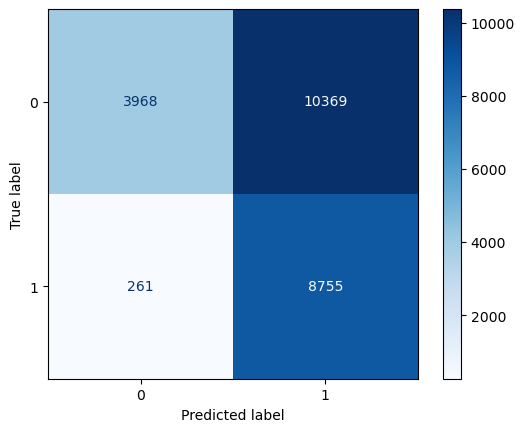

In [48]:
eval_model(model_check_4,test_dl)


Detailed Evaluation Metrics:
Accuracy: 64.46%
Macro Precision: 0.7448
Macro Recall: 0.7063
Micro Precision: 0.6446
Micro Recall: 0.6446
Macro F1-Score: 0.6446
Micro F1-Score: 0.6402


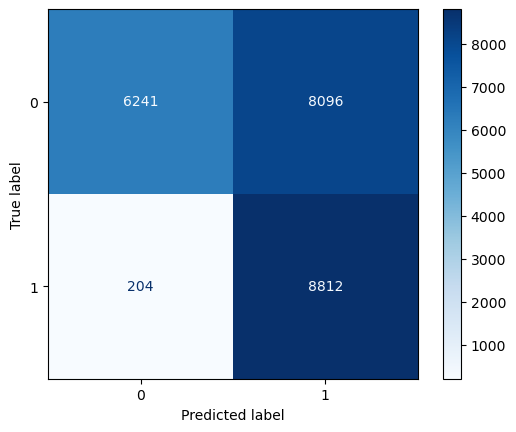

In [49]:
model_check_7 = VGG16()

checkpoint = torch.load(checkpoints_path+"vgg_mod_checpt7.pt")

model_check_7.load_state_dict(checkpoint['model_state_dict'])
eval_model(model_check_7,test_dl)


Detailed Evaluation Metrics:
Accuracy: 57.65%
Macro Precision: 0.7026
Macro Recall: 0.6475
Micro Precision: 0.5765
Micro Recall: 0.5765
Macro F1-Score: 0.5765
Micro F1-Score: 0.5647


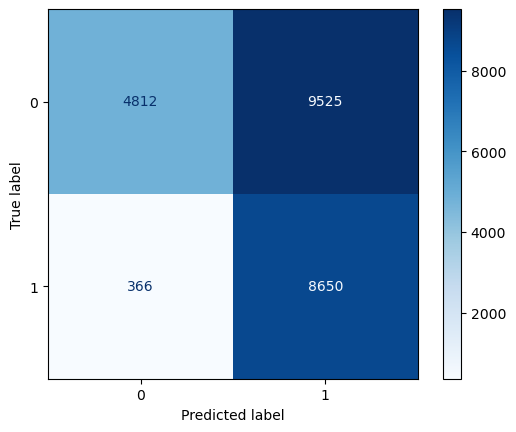

In [50]:
model_check_11 = VGG16()

checkpoint = torch.load(checkpoints_path+"vgg_mod_checpt11.pt")

model_check_11.load_state_dict(checkpoint['model_state_dict'])
eval_model(model_check_11,test_dl)


Detailed Evaluation Metrics:
Accuracy: 74.50%
Macro Precision: 0.7654
Macro Recall: 0.7748
Micro Precision: 0.7450
Micro Recall: 0.7450
Macro F1-Score: 0.7450
Micro F1-Score: 0.7445


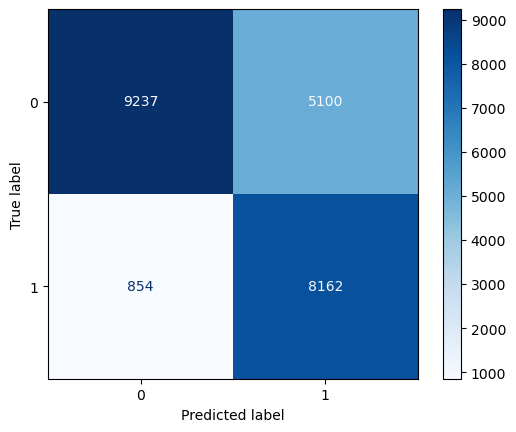

In [51]:
final_model = VGG16()

checkpoint = torch.load(checkpoints_path+"vgg16_weights_final.pt")

final_model.load_state_dict(checkpoint)
eval_model(final_model,test_dl)

In [20]:
from transformers import Trainer, TrainingArguments
from stop_words import get_stop_words
from transformers import AutoModelForSequenceClassification
import torch
checkpoints_path = '/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/vgg16_checpoints/'
checkpoint_path = '/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/results/checkpoint-74728'
bert_model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint_path,
        num_labels=2,                  # This MUST match what you trained with
        dtype=torch.float16,     # Forces it to expect the 1080 Ti's fp16 weights
        device_map="auto"              # Automatically figures out the safest way to load it
    )
VGG_model = VGG16()

checkpoint = torch.load(checkpoints_path+"vgg16_weights_final.pt")

VGG_model.load_state_dict(checkpoint)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1805.86it/s]


<All keys matched successfully>

In [ ]:

class combined_model(nn.Module):
    def __init__(self,text_model,image_model num_classes=2):
        super().__init__()
        self.text=text_model
        self.image = image_model
        
        
    def forward(self, x):
        #image = x["img"]
        #text = x['text']
        #img_result = image_model(image)
        #
        return out